In [1]:
import pandas as pd

In [2]:
df_Ventas = pd.read_csv("../DatasetsInicio/CochesVentas_actualizado.csv", encoding="utf-8")
df_Marcas = pd.read_csv("../DatasetsInicio/InfoMarcas_actualizado.csv", encoding="utf-8")
df_Coches = pd.read_csv("../DatasetsInicio/ModelosCoches_actualizado.csv", encoding="utf-8")
df_Personas = pd.read_csv("../DatasetsInicio/Personas_actualizado.csv", encoding="utf-8")

In [3]:
df_Ventas.head()

,year,make,model,trim,body,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
0,2015,Kia,Sorento,LX,SUV,5xyktca69fg566472,ca,5.0,16639.0,white,black,kia motors america inc,20500.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
1,2015,Kia,Sorento,LX,SUV,5xyktca69fg561319,ca,5.0,9393.0,white,beige,kia motors america inc,20800.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
2,2014,BMW,3 Series,328i SULEV,Sedan,wba3c1c51ek116351,ca,45.0,1331.0,gray,black,financial services remarketing (lease),31900.0,30000.0,Thu Jan 15 2015 04:30:00 GMT-0800 (PST)
3,2015,Volvo,S60,T5,Sedan,yv1612tb4f1310987,ca,41.0,14282.0,white,black,volvo na rep/world omni,27500.0,27750.0,Thu Jan 29 2015 04:30:00 GMT-0800 (PST)
4,2014,BMW,6 Series Gran Coupe,650i,Sedan,wba6b2c57ed129731,ca,43.0,2641.0,gray,black,financial services remarketing (lease),66000.0,67000.0,Thu Dec 18 2014 12:30:00 GMT-0800 (PST)


Vamos a quitar la columna vin por que es un código único de cada Coche.

Investigando un poco, vemos que MMR (Manheim Market Report) significa el precio en general por el que se esta vendiendo el coche en Estados Unidos por tanto vamos a quitarlo por que sería darle demasiadas pistas al modelo.

In [4]:
df_Ventas = df_Ventas.drop(columns=["vin", "mmr", "state", "saledate", "seller", "body"])

In [5]:
df_Ventas

,year,make,model,trim,condition,odometer,color,interior,sellingprice
0,2015,Kia,Sorento,LX,5.0,16639.0,white,black,21500.0
1,2015,Kia,Sorento,LX,5.0,9393.0,white,beige,21500.0
2,2014,BMW,3 Series,328i SULEV,45.0,1331.0,gray,black,30000.0
3,2015,Volvo,S60,T5,41.0,14282.0,white,black,27750.0
4,2014,BMW,6 Series Gran Coupe,650i,43.0,2641.0,gray,black,67000.0
...,...,...,...,...,...,...,...,...,...
558832,2015,Kia,K900,Luxury,45.0,18255.0,silver,black,33000.0
558833,2012,Ram,2500,Power Wagon,5.0,54393.0,white,black,30800.0
558834,2012,BMW,X5,xDrive35d,48.0,50561.0,black,black,34000.0
558835,2015,Nissan,Altima,2.5 S,38.0,16658.0,white,black,11100.0


In [6]:
df_Coches.head()

,Make,Model,Combined Mpg For Fuel Type1,Cylinders,Engine displacement,Drive,Annual Fuel Cost For Fuel Type1,Annual Fuel Cost For Fuel Type2,Fuel Type1,Unrounded Highway Mpg For Fuel Type1,ID,MPG Data,Transmission,Unadjusted Highway Mpg For Fuel Type1,Vehicle Size Class,Year,baseModel,Unnamed: 17
0,Mercedes-Benz,E350 Convertible,20,6.0,3.5,Rear-Wheel Drive,3350.0,0.0,Premium Gasoline,248.246,30044.0,N,Automatic 7-spd,34.9,Subcompact Cars,2011,E-Class,NaN
1,Porsche,Cayman S,23,6.0,3.4,Rear-Wheel Drive,2950.0,0.0,Premium Gasoline,287.511,31101.0,N,Automatic 7-spd,409.778,Two Seaters,2012,Cayman,NaN
2,Honda,Accord,27,4.0,2.4,Front-Wheel Drive,2000.0,0.0,Regular Gasoline,327.688,31787.0,Y,Manual 5-spd,473.728,Large Cars,2012,Accord,NaN
3,Jeep,Compass 4WD,23,4.0,2.4,4-Wheel Drive,2350.0,0.0,Regular Gasoline,25.478,31967.0,Y,Automatic (variable gear ratios),35.9,Sport Utility Vehicle - 4WD,2012,Compass,NaN
4,Toyota,Cressida,19,6.0,2.8,Rear-Wheel Drive,3550.0,0.0,Premium Gasoline,0.0,3328.0,N,Manual 5-spd,307.692,Compact Cars,1987,Cressida,NaN


In [7]:
df_Coches.describe()

,Cylinders,Engine displacement,Annual Fuel Cost For Fuel Type1,Annual Fuel Cost For Fuel Type2,ID
count,46722.000000,46724.000000,45727.000000,45737.000000,45737.000000
mean,5.699991,3.273393,2990.644477,94.038743,23214.544461
std,1.774104,1.354787,886.151920,588.168880,13641.215216
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.000000,2.200000,2450.000000,0.000000,11429.000000
50%,6.000000,3.000000,2950.000000,0.000000,22979.000000
75%,6.000000,4.200000,3550.000000,0.000000,34845.000000
max,16.000000,8.400000,9600.000000,5200.000000,47965.000000


In [8]:
df_Coches["MPG Data"].unique()

array(['N', 'Y', nan, '0', '15'], dtype=object)

Quitaremos los ID ya que son datos únicos

In [9]:
df_Coches = df_Coches.drop(columns=["ID", "Annual Fuel Cost For Fuel Type1",
                                    "Annual Fuel Cost For Fuel Type2", 
                                    "Unrounded Highway Mpg For Fuel Type1", 
                                    "Unadjusted Highway Mpg For Fuel Type1",
                                    "baseModel", "MPG Data", "Unnamed: 17"])

In [10]:
df_Coches.head()

,Make,Model,Combined Mpg For Fuel Type1,Cylinders,Engine displacement,Drive,Fuel Type1,Transmission,Vehicle Size Class,Year
0,Mercedes-Benz,E350 Convertible,20,6.0,3.5,Rear-Wheel Drive,Premium Gasoline,Automatic 7-spd,Subcompact Cars,2011
1,Porsche,Cayman S,23,6.0,3.4,Rear-Wheel Drive,Premium Gasoline,Automatic 7-spd,Two Seaters,2012
2,Honda,Accord,27,4.0,2.4,Front-Wheel Drive,Regular Gasoline,Manual 5-spd,Large Cars,2012
3,Jeep,Compass 4WD,23,4.0,2.4,4-Wheel Drive,Regular Gasoline,Automatic (variable gear ratios),Sport Utility Vehicle - 4WD,2012
4,Toyota,Cressida,19,6.0,2.8,Rear-Wheel Drive,Premium Gasoline,Manual 5-spd,Compact Cars,1987


In [11]:
df_Marcas.head()

,Marca,País de Origen,Año de Fundación,Estado Actual,Grupo Automovilístico,Segmento Principal,Tipo de Motorización Destacada,Modelos Más Vendidos/Icónicos,Ventas Anuales (Aprox. Global 2023),Sede Principal,Nota Histórica Relevante,Ventas
0,Ford,EE. UU.,1903.0,Activa,Ford Motor Company,Generalista/Pick-up,Gasolina/Eléctrico,Mustang,4400000,Dearborn,Pionero en la línea de ensamblaje móvil,4400000.0
1,Dodge,EE. UU.,1900.0,Activa,Stellantis,Generalista/Performance,Gasolina V8,Challenger,200000,Auburn Hills,Enfocada en vehículos 'muscle car' y alto rend...,200000.0
2,Cadillac,EE. UU.,1902.0,Activa,General Motors (GM),Lujo/Premium,Gasolina/Eléctrico,Escalade,300000,Detroit,División de lujo de GM pionera en motores V8 y...,300000.0
3,Toyota,Japón,1937.0,Activa,Toyota Motor Corp.,Generalista,Híbrida/Gasolina,Corolla,10500000,Toyota City,Uno de los mayores fabricantes del mundo líder...,10500000.0
4,Acura,Japón,1986.0,Activa,Honda Motor Company,Lujo/Premium,Gasolina/Híbrida,MDX,130000,Minato,Primera división de lujo de una marca japonesa...,130000.0


Esta tabla no la vamos a juntar ya que no aporta nada relevante al modelo

In [12]:
df_Personas

,Car_id,Date,Customer Name,Gender,Annual Income,Dealer_Name,Company,Model,Dealer_No,Body Style,Phone,Dealer_Region
0,C_CND_000001,1/2/2022,Geraldine,Male,13500,Buddy Storbeck's Diesel Service Inc,Ford,Expedition,06457-3834,SUV,8264678,Middletown
1,C_CND_000002,1/2/2022,Gia,Male,1480000,C & M Motors Inc,Dodge,Durango,60504-7114,SUV,6848189,Aurora
2,C_CND_000003,1/2/2022,Gianna,Male,1035000,Capitol KIA,Cadillac,Eldorado,38701-8047,Passenger,7298798,Greenville
3,C_CND_000004,1/2/2022,Giselle,Male,13500,Chrysler of Tri-Cities,Toyota,Celica,99301-3882,SUV,6257557,Pasco
4,C_CND_000005,1/2/2022,Grace,Male,1465000,Chrysler Plymouth,Acura,TL,53546-9427,Hatchback,7081483,Janesville
...,...,...,...,...,...,...,...,...,...,...,...,...
23901,C_CND_023902,12/31/2023,Martin,Male,13500,C & M Motors Inc,Plymouth,Voyager,60504-7114,Passenger,8583598,Pasco
23902,C_CND_023903,12/31/2023,Jimmy,Female,900000,Ryder Truck Rental and Leasing,Chevrolet,Prizm,06457-3834,Hardtop,7914229,Middletown
23903,C_CND_023904,12/31/2023,Emma,Male,705000,Chrysler of Tri-Cities,BMW,328i,99301-3882,Sedan,7659127,Scottsdale
23904,C_CND_023905,12/31/2023,Victoire,Male,13500,Chrysler Plymouth,Chevrolet,Metro,53546-9427,Passenger,6030764,Austin


In [13]:
df_Personas["Dealer_Name"].unique()

array(["Buddy Storbeck's Diesel Service Inc", 'C & M Motors Inc',
       'Capitol KIA', 'Chrysler of Tri-Cities', 'Chrysler Plymouth',
       'Classic Chevy', 'Clay Johnson Auto Sales', 'U-Haul CO',
       'Rabun Used Car Sales', 'Race Car Help', 'Saab-Belle Dodge',
       'Scrivener Performance Engineering', 'Diehl Motor CO Inc',
       'Star Enterprises Inc', 'Suburban Ford', 'Tri-State Mack Inc',
       'Progressive Shippers Cooperative Association No',
       'Ryder Truck Rental and Leasing', 'Enterprise Rent A Car',
       'Gartner Buick Hyundai Saab', 'Hatfield Volkswagen',
       'Iceberg Rentals', 'McKinney Dodge Chrysler Jeep',
       'Motor Vehicle Branch Office', 'Nebo Chevrolet',
       'New Castle Ford Lincoln Mercury', 'Pars Auto Sales',
       'Pitre Buick-Pontiac-Gmc of Scottsdale'], dtype=object)

In [14]:
df_Personas.columns

Index(['Car_id', 'Date', 'Customer Name', 'Gender', 'Annual Income',
       'Dealer_Name', 'Company', 'Model', 'Dealer_No ', 'Body Style', 'Phone',
       'Dealer_Region'],
      dtype='object')

De la tabla de Personas, borraremos columnas únicas e innecesarias para nuestro modelo, como son el ID, la fecha, el nombre del comprador, el nombre del vendedor, el número del vendedor, el cuerpo del coche por que lo cogemos de la tabla de coches y el número de teléfono del comprador. 


In [15]:
df_Personas = df_Personas.drop(columns=['Car_id', 'Date', 'Customer Name',
                                        'Dealer_No ', 'Body Style', 'Phone'])

In [16]:
df_Personas

,Gender,Annual Income,Dealer_Name,Company,Model,Dealer_Region
0,Male,13500,Buddy Storbeck's Diesel Service Inc,Ford,Expedition,Middletown
1,Male,1480000,C & M Motors Inc,Dodge,Durango,Aurora
2,Male,1035000,Capitol KIA,Cadillac,Eldorado,Greenville
3,Male,13500,Chrysler of Tri-Cities,Toyota,Celica,Pasco
4,Male,1465000,Chrysler Plymouth,Acura,TL,Janesville
...,...,...,...,...,...,...
23901,Male,13500,C & M Motors Inc,Plymouth,Voyager,Pasco
23902,Female,900000,Ryder Truck Rental and Leasing,Chevrolet,Prizm,Middletown
23903,Male,705000,Chrysler of Tri-Cities,BMW,328i,Scottsdale
23904,Male,13500,Chrysler Plymouth,Chevrolet,Metro,Austin


In [17]:
df_Personas.rename(columns={ 
    "Company": "Marca",
    "Model": "Modelo",
    "Gender": "Genero",
    "Annual Income" : "Salario_Anual",
    "Dealer_Name" : "Nombre_Vendedor",
    "Dealer_Region" : "Region_Vendedor",
}, inplace=True)

df_Ventas.rename(columns={ 
    "make": "Marca",
    "model": "Modelo",
    "trim" : "SubModelo",
    "condition" : "Condicion",
    "sellingprice": "Precio",
    "year": "Anio",
    "condicion" : "Condicion",
    "interior" : "Interior",
    "color" : "Color",
    "odometer" : "Millas"
}, inplace=True)

df_Coches.rename(columns={ 
    "Make": "Marca",
    "Model": "Modelo",
    "Year": "Anio",
    "Combined Mpg For Fuel Type1": "MPG",
    "Fuel Type1": "Combustible",
    "Cylinders": "Cilindros",
    "Engine displacement": "Motor",
    "Drive" : "Traccion",
    "Transmission" : "Transmision",
    "Vehicle Size Class" : "Tamanio_del_vehiculo"
}, inplace=True)


In [18]:
df_Personas

,Genero,Salario_Anual,Nombre_Vendedor,Marca,Modelo,Region_Vendedor
0,Male,13500,Buddy Storbeck's Diesel Service Inc,Ford,Expedition,Middletown
1,Male,1480000,C & M Motors Inc,Dodge,Durango,Aurora
2,Male,1035000,Capitol KIA,Cadillac,Eldorado,Greenville
3,Male,13500,Chrysler of Tri-Cities,Toyota,Celica,Pasco
4,Male,1465000,Chrysler Plymouth,Acura,TL,Janesville
...,...,...,...,...,...,...
23901,Male,13500,C & M Motors Inc,Plymouth,Voyager,Pasco
23902,Female,900000,Ryder Truck Rental and Leasing,Chevrolet,Prizm,Middletown
23903,Male,705000,Chrysler of Tri-Cities,BMW,328i,Scottsdale
23904,Male,13500,Chrysler Plymouth,Chevrolet,Metro,Austin


In [19]:
def normalizar_columna(col):
    return col.fillna("").str.strip().str.lower()

Vamos a juntar las tablas para así tener solo una tabla en la que trabajaremos.

Primero normalizaremos las columnas para que no nos falta ninguna fila por eso

In [20]:
df_Ventas["make_norm"] = normalizar_columna(df_Ventas["Marca"])
df_Ventas["model_norm"] = normalizar_columna(df_Ventas["Modelo"])
df_Ventas["trim_norm"] = normalizar_columna(df_Ventas["SubModelo"])
df_Personas["Company_norm"] = normalizar_columna(df_Personas["Marca"])
df_Personas["Model_norm"] = normalizar_columna(df_Personas["Modelo"])
df_Personas["Company_norm"] = df_Personas["Company_norm"].replace("mercedes-b", "mercedes-benz")
df_Ventas["make_norm"] = df_Ventas["make_norm"].replace("mercedes-b", "mercedes-benz")

In [21]:
from collections import defaultdict, deque
import pandas as pd

resultados = []

# --- 1. Crear dos diccionarios para buscar coches ---
coches_por_model = defaultdict(deque)
coches_por_trim = defaultdict(deque)

for row in df_Ventas.itertuples(index=False):
    key_model = (row.make_norm, row.model_norm)
    key_trim = (row.make_norm, getattr(row, "trim_norm", None))
    
    coches_por_model[key_model].append(row)
    if row.SubModelo:  # sólo si existe valor
        coches_por_trim[key_trim].append(row)

# --- 2. Asignar coches a cada persona ---
for persona in df_Personas.itertuples(index=False):
    key = (persona.Company_norm, persona.Model_norm)
    
    coche_asignado = None
    if key in coches_por_model and coches_por_model[key]:
        coche_asignado = coches_por_model[key].popleft()
    elif key in coches_por_trim and coches_por_trim[key]:
        coche_asignado = coches_por_trim[key].popleft()
    
    if coche_asignado:
        fila_persona = persona._asdict()
        fila_coches = coche_asignado._asdict()

        # Eliminar columnas normalizadas
        for col in ["Company_norm", "Model_norm"]:
            fila_persona.pop(col, None)
        for col in ["make_norm", "model_norm", "trim_norm"]:
            fila_coches.pop(col, None)

        # Combinar resultados
        fila_combinada = {**fila_coches, **fila_persona}
        resultados.append(fila_combinada)
    else:
        print(f"No hay coches disponibles para: {persona.Marca} {persona.Modelo}")

# --- 3. Guardar resultado ---
df_final = pd.DataFrame(resultados)
print(f"Asignación completa guardada. Total asignaciones: {len(df_final)}")


No hay coches disponibles para: Chrysler Sebring Coupe
No hay coches disponibles para: Porsche Carrera Cabrio
No hay coches disponibles para: Saturn LW
No hay coches disponibles para: Chrysler Sebring Coupe
No hay coches disponibles para: Saturn SW
No hay coches disponibles para: Mercedes-B SLK
No hay coches disponibles para: Dodge Ram Pickup
No hay coches disponibles para: Lexus ES300
No hay coches disponibles para: Lexus GS400
No hay coches disponibles para: Chrysler Sebring Coupe
No hay coches disponibles para: Saturn LW
No hay coches disponibles para: Chevrolet Metro
No hay coches disponibles para: Lexus ES300
No hay coches disponibles para: Saab 5-Sep
No hay coches disponibles para: Lexus LS400
No hay coches disponibles para: Saturn SW
No hay coches disponibles para: Mercedes-B SLK
No hay coches disponibles para: Saturn LS
No hay coches disponibles para: Lexus GS400
No hay coches disponibles para: Porsche Carrera Cabrio
No hay coches disponibles para: Mercedes-B SLK
No hay coches 

In [22]:
df_final

,Anio,Marca,Modelo,SubModelo,Condicion,Millas,Color,Interior,Precio,Genero,Salario_Anual,Nombre_Vendedor,Region_Vendedor
0,2012,Ford,Expedition,Limited,43.0,68150.0,white,tan,27200.0,Male,13500,Buddy Storbeck's Diesel Service Inc,Middletown
1,2008,Dodge,Durango,SXT,41.0,135722.0,black,gray,4500.0,Male,1480000,C & M Motors Inc,Aurora
2,1999,Cadillac,Eldorado,Touring,32.0,82173.0,gray,beige,900.0,Male,1035000,Capitol KIA,Greenville
3,2004,Toyota,Celica,GTS,19.0,170813.0,black,black,2000.0,Male,13500,Chrysler of Tri-Cities,Pasco
4,2012,Acura,TL,Base,41.0,28395.0,gray,black,20200.0,Male,1465000,Chrysler Plymouth,Janesville
...,...,...,...,...,...,...,...,...,...,...,...,...,...
14542,2012,Chevrolet,Corvette,GS,44.0,6328.0,silver,black,43800.0,Male,2340000,Ryder Truck Rental and Leasing,Middletown
14543,2012,BMW,528i,528i,36.0,50672.0,white,—,25000.0,Female,975000,Tri-State Mack Inc,Scottsdale
14544,1999,Mercury,Sable,LS,23.0,175329.0,black,tan,600.0,Male,965000,Progressive Shippers Cooperative Association No,Middletown
14545,2013,Mercedes-B,E-Class,E350 Sport,43.0,22580.0,—,off-white,34000.0,Male,520000,Progressive Shippers Cooperative Association No,Greenville


In [23]:
# --- Normalización de columnas ---
df_Coches["make_norm"] = normalizar_columna(df_Coches["Marca"])
df_Coches["model_norm"] = normalizar_columna(df_Coches["Modelo"])
df_Coches["make_norm"] = df_Coches["make_norm"].replace("mercedes-b", "mercedes-benz")
df_final["make_norm"] = normalizar_columna(df_final["Marca"])
df_final["model_norm"] = normalizar_columna(df_final["Modelo"])
df_final["make_norm"] = df_final["make_norm"].replace("mercedes-b", "mercedes-benz")

resultados = []
no_encontrados_final = []   # No encontrados de df_final
coches_usados = set()       # Para rastrear qué filas de df_Coches fueron emparejadas

# --- 1. Crear diccionario con las filas de df_Coches ---
coches_por_model = defaultdict(deque)

for idx, row in enumerate(df_Coches.itertuples(index=False)):
    make_coche = getattr(row, "make_norm", None)
    model_coche = getattr(row, "model_norm", None)
    
    # Tomar solo la primera palabra del modelo
    first_word_model = model_coche.split()[0] if isinstance(model_coche, str) and model_coche else model_coche
    
    key = (make_coche, first_word_model)
    coches_por_model[key].append((idx, row))  

# --- 2. Emparejar df_final con df_Coches ---
for fila in df_final.itertuples(index=False):
    make = getattr(fila, "make_norm", None)
    model = getattr(fila, "model_norm", None)
    
    # También usar solo la primera palabra del modelo
    first_word_model = model.split()[0] if isinstance(model, str) and model else model
    
    key_simple = (make, first_word_model)
    coche_encontrado = None
    idx_coche = None

    if key_simple in coches_por_model and coches_por_model[key_simple]:
        idx_coche, coche_encontrado = coches_por_model[key_simple].popleft()

    fila_dict = fila._asdict()

    if coche_encontrado:
        coches_usados.add(idx_coche)  # Marcar ese coche como usado
        fila_extra = coche_encontrado._asdict()
        for col in ["make_norm", "model_norm", "trim_norm"]:
            fila_extra.pop(col, None)
        fila_combinada = {**fila_dict, **fila_extra}
        resultados.append(fila_combinada)
    else:
        #Guardamos la fila de df_final no emparejada
        no_encontrados_final.append(fila_dict)

# --- 3. Crear DataFrames ---
df_final = pd.DataFrame(resultados)
df_no_encontrados_final = pd.DataFrame(no_encontrados_final)

# --- 4. Cálculo de coches de df_Coches no emparejados ---
no_usados_idx = set(range(len(df_Coches))) - coches_usados
df_no_usados_coches = df_Coches.iloc[list(no_usados_idx)].copy()

# --- 5. Eliminar columnas normalizadas ---
for df_ in [df_final, df_no_encontrados_final, df_no_usados_coches]:
    df_.drop(columns=["make_norm", "model_norm", "trim_norm"], errors="ignore", inplace=True)

# --- 6. Reporte ---
print(f"Integración completa. Total filas integradas: {len(df_final)}")
print(f"Coches no encontrados en df_final: {len(df_no_encontrados_final)}")
print(f"Coches no utilizados de df_Coches: {len(df_no_usados_coches)}")

if not df_no_encontrados_final.empty:
    print("\n Coches de df_final sin coincidencia:")
    display(df_no_encontrados_final.head(10))

if not df_no_usados_coches.empty:
    print("\n Coches de df_Coches no emparejados:")
    display(df_no_usados_coches.head(10))

if df_no_encontrados_final.empty and df_no_usados_coches.empty:
    print(" Todos los coches fueron emparejados correctamente.")



Integración completa. Total filas integradas: 7873
Coches no encontrados en df_final: 6674
Coches no utilizados de df_Coches: 39650

 Coches de df_final sin coincidencia:


,Anio,Marca,Modelo,SubModelo,Condicion,Millas,Color,Interior,Precio,Genero,Salario_Anual,Nombre_Vendedor,Region_Vendedor
0,1998,Mitsubishi,3000GT,Base,2.0,216279.0,red,beige,2000.0,Male,210000,Saab-Belle Dodge,Austin
1,2013,Mercedes-B,C-Class,C250,42.0,20705.0,—,black,25750.0,Male,566000,Gartner Buick Hyundai Saab,Greenville
2,2013,Mercedes-B,C-Class,C250 Sport,45.0,20161.0,white,black,25000.0,Male,890000,Buddy Storbeck's Diesel Service Inc,Middletown
3,2013,Mercedes-B,C-Class,C250 Sport,28.0,31978.0,black,black,21000.0,Male,393000,Iceberg Rentals,Janesville
4,2013,Mercedes-B,M-Class,ML350,5.0,6536.0,silver,black,42750.0,Male,440000,McKinney Dodge Chrysler Jeep,Austin
5,2004,Chrysler,300M,Base,NaN,114345.0,black,—,2200.0,Male,13500,Race Car Help,Austin
6,2004,Chrysler,300M,Base,19.0,177385.0,burgundy,gray,850.0,Male,13500,Chrysler of Tri-Cities,Pasco
7,2012,Mercedes-B,SL-Class,SL550,45.0,19491.0,black,black,58750.0,Male,659000,Buddy Storbeck's Diesel Service Inc,Janesville
8,2013,Mercedes-B,M-Class,ML350,NaN,32532.0,NaN,NaN,34500.0,Female,1220000,Scrivener Performance Engineering,Greenville
9,2012,Mercedes-B,SL-Class,SL550,39.0,26776.0,silver,black,20500.0,Male,642000,Suburban Ford,Greenville



 Coches de df_Coches no emparejados:


,Marca,Modelo,MPG,Cilindros,Motor,Traccion,Combustible,Transmision,Tamanio_del_vehiculo,Anio
0,Mercedes-Benz,E350 Convertible,20,6.0,3.5,Rear-Wheel Drive,Premium Gasoline,Automatic 7-spd,Subcompact Cars,2011
1,Porsche,Cayman S,23,6.0,3.4,Rear-Wheel Drive,Premium Gasoline,Automatic 7-spd,Two Seaters,2012
3,Jeep,Compass 4WD,23,4.0,2.4,4-Wheel Drive,Regular Gasoline,Automatic (variable gear ratios),Sport Utility Vehicle - 4WD,2012
4,Toyota,Cressida,19,6.0,2.8,Rear-Wheel Drive,Premium Gasoline,Manual 5-spd,Compact Cars,1987
6,Mercedes-Benz,E350 4matic Coupe,23,6.0,3.5,4-Wheel Drive,NaN,NaN,NaN,NaN
7,BMW,535d,30,6.0,3.0,Rear-Wheel Drive,Diesel,Automatic (S8),Midsize Cars,2015
8,Chevrolet,R10 Pickup 2WD,16,6.0,4.3,Rear-Wheel Drive,Regular Gasoline,Automatic 3-spd,Standard Pickup Trucks,1987
9,Chrysler,300 AWD,21,6.0,3.6,All-Wheel Drive,Regular Gasoline,Automatic 8-spd,Large Cars,2016
10,Tesla,Model S AWD - 75D,103,NaN,NaN,All-Wheel Drive,Electricity,Automatic (A1),Large Cars,2017
11,Chevrolet,Cruze,37,4.0,1.6,Front-Wheel Drive,Diesel,Automatic 9-spd,Compact Cars,2018


In [24]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7873 entries, 0 to 7872
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Anio                  7656 non-null   object 
 1   Marca                 7873 non-null   object 
 2   Modelo                7873 non-null   object 
 3   SubModelo             7807 non-null   object 
 4   Condicion             5905 non-null   float64
 5   Millas                7864 non-null   float64
 6   Color                 7845 non-null   object 
 7   Interior              7845 non-null   object 
 8   Precio                7873 non-null   float64
 9   Genero                7873 non-null   object 
 10  Salario_Anual         7873 non-null   int64  
 11  Nombre_Vendedor       7873 non-null   object 
 12  Region_Vendedor       7873 non-null   object 
 13  MPG                   7873 non-null   object 
 14  Cilindros             7843 non-null   float64
 15  Motor                

In [25]:
from collections import defaultdict, deque
import pandas as pd

# --- 1. Normalización de columnas ---
df_Ventas["make_norm"] = normalizar_columna(df_Ventas["Marca"])
df_Ventas["model_norm"] = normalizar_columna(df_Ventas["Modelo"])
df_Ventas["make_norm"] = df_Ventas["make_norm"].replace("mercedes-b", "mercedes-benz")

df_Coches["make_norm"] = normalizar_columna(df_Coches["Marca"])
df_Coches["model_norm"] = normalizar_columna(df_Coches["Modelo"])
df_Coches["make_norm"] = df_Coches["make_norm"].replace("mercedes-b", "mercedes-benz")

# --- 2. Crear diccionario con las filas de df_Coches ---
coches_por_model = defaultdict(deque)
for idx, row in enumerate(df_Coches.itertuples(index=False)):
    make_coche = getattr(row, "make_norm", None)
    model_coche = getattr(row, "model_norm", None)
    first_word_model = model_coche.split()[0] if isinstance(model_coche, str) and model_coche else model_coche
    key = (make_coche, first_word_model)
    coches_por_model[key].append((idx, row))

# --- 3. Emparejar df_Ventas con df_Coches ---
resultados = []
no_encontrados_ventas = []
coches_usados = set()

for fila in df_Ventas.itertuples(index=False):
    make = getattr(fila, "make_norm", None)
    model = getattr(fila, "model_norm", None)
    first_word_model = model.split()[0] if isinstance(model, str) and model else model

    key_simple = (make, first_word_model)
    coche_encontrado = None
    idx_coche = None

    # Intentar coincidencia
    if key_simple in coches_por_model and coches_por_model[key_simple]:
        idx_coche, coche_encontrado = coches_por_model[key_simple].popleft()

    fila_dict = fila._asdict()

    if coche_encontrado:
        coches_usados.add(idx_coche)
        fila_extra = coche_encontrado._asdict()
        for col in ["make_norm", "model_norm", "trim_norm"]:
            fila_extra.pop(col, None)
        fila_combinada = {**fila_dict, **fila_extra}
        resultados.append(fila_combinada)
    else:
        no_encontrados_ventas.append(fila_dict)

# --- 4. Crear DataFrames finales ---
df_final = pd.DataFrame(resultados)
df_no_encontrados_ventas = pd.DataFrame(no_encontrados_ventas)

# --- 5. Calcular coches no usados ---
no_usados_idx = set(range(len(df_Coches))) - coches_usados
df_no_usados_coches = df_Coches.iloc[list(no_usados_idx)].copy()

# --- 6. Limpiar columnas normalizadas ---
for df_ in [df_final, df_no_encontrados_ventas, df_no_usados_coches]:
    df_.drop(columns=["make_norm", "model_norm", "trim_norm"], errors="ignore", inplace=True)

# --- 7. Resultados ---
print(f"Emparejamiento completado. Total emparejados: {len(df_final)}")
print(f"Ventas sin coche: {len(df_no_encontrados_ventas)}")
print(f"Coches sin usar: {len(df_no_usados_coches)}")


Emparejamiento completado. Total emparejados: 26808
Ventas sin coche: 532029
Coches sin usar: 20715


# **Descripción detallada del DataFrame Final**

Este DataFrame es el resultado de integrar y depurar información procedente de dos fuentes principales del proyecto:

* **DatasetCoches.csv** → Datos sobre transacciones y precios de venta reales de vehículos.
* **AllVehiclesModel.csv** → Especificaciones técnicas y eficiencia energética de cada modelo.

El objetivo de esta integración es construir un conjunto unificado y depurado que combine variables técnicas, comerciales y de usuario, facilitando el análisis exploratorio, la visualización y el desarrollo de modelos predictivos.

---

### **1. Anio**

* **Origen:** DatasetCoches.csv
* **Descripción:** Año del modelo o del registro de venta del vehículo.
* **Tipo:** float64
* **Uso analítico:** Permite medir la evolución de precios, analizar la antigüedad de los coches vendidos o estudiar tendencias temporales en el mercado.

---

### **2. Marca**

* **Origen:** DatasetCoches.csv / AllVehiclesModel.csv
* **Descripción:** Fabricante o marca del vehículo (ej. Ford, BMW, Toyota…).
* **Tipo:** object
* **Uso analítico:** Clave para agrupar ventas, analizar cuotas de mercado o estudiar diferencias técnicas y económicas entre fabricantes.

---

### **3. Modelo**

* **Origen:** DatasetCoches.csv / AllVehiclesModel.csv
* **Descripción:** Denominación comercial del modelo principal del coche (ej. Focus, Civic, A3…).
* **Tipo:** object
* **Uso analítico:** Permite vincular precios, consumo y características técnicas con un modelo específico.

---

### **4. SubModelo**

* **Origen:** DatasetCoches.csv (trim o subversión del modelo)
* **Descripción:** Variante específica dentro de un modelo (ej. Focus Titanium, Golf GTI…).
* **Tipo:** object
* **Uso analítico:** Aporta granularidad al análisis de precios y equipamientos dentro de un mismo modelo.

---

### **5. Condicion**

* **Origen:** DatasetCoches.csv (condition)
* **Descripción:** Estado o nivel de conservación del coche (escala numérica o categórica).
* **Tipo:** float64
* **Uso analítico:** Variable clave para explicar variaciones de precio y comportamiento del mercado de segunda mano.

---

### **6. Color**

* **Origen:** DatasetCoches.csv / Personas.csv
* **Descripción:** Color exterior del vehículo.
* **Tipo:** object
* **Uso analítico:** Permite estudiar preferencias estéticas, relación con precios o diferencias entre regiones o marcas.

---

### **7. Interior**

* **Origen:** DatasetCoches.csv
* **Descripción:** Color o tipo de acabado interior del coche.
* **Tipo:** object
* **Uso analítico:** Puede usarse para analizar combinaciones estéticas o segmentaciones por gama (lujo, deportiva, etc.).

---

### **8. Precio**

* **Origen:** DatasetCoches.csv (sellingprice o price)
* **Descripción:** Precio final o de venta registrado para cada vehículo.
* **Tipo:** float64
* **Uso analítico:** Variable económica principal; se utiliza como objetivo para regresiones o para comparar segmentos de mercado.

---

### **9. MPG (Miles per Gallon)**

* **Origen:** AllVehiclesModel.csv (Combined Mpg For Fuel Type1)
* **Descripción:** Eficiencia de combustible medida en millas por galón.
* **Tipo:** int64
* **Uso analítico:** Indicador clave de rendimiento y sostenibilidad. Permite estudiar la relación entre eficiencia, tipo de combustible y precio.

---

### **10. Cilindros**

* **Origen:** AllVehiclesModel.csv (Cylinders)
* **Descripción:** Número de cilindros del motor.
* **Tipo:** float64
* **Uso analítico:** Refleja el tamaño y potencia del motor; correlaciona con consumo, emisiones y coste del vehículo.

---

### **11. Motor**

* **Origen:** AllVehiclesModel.csv (Engine displacement)
* **Descripción:** Cilindrada o volumen del motor (litros o cc).
* **Tipo:** float64
* **Uso analítico:** Relacionada directamente con potencia y emisiones. Indicador técnico útil para clasificar tipos de vehículo.

---

### **12. Traccion**

* **Origen:** AllVehiclesModel.csv (Drive)
* **Descripción:** Tipo de tracción del vehículo (FWD, RWD, AWD, etc.).
* **Tipo:** object
* **Uso analítico:** Permite distinguir configuraciones técnicas y su influencia en consumo, rendimiento o precio.

---

### **13. Combustible**

* **Origen:** AllVehiclesModel.csv (Fuel Type1)
* **Descripción:** Tipo de combustible principal (Gasoline, Diesel, Electric, Hybrid…).
* **Tipo:** object
* **Uso analítico:** Esencial para segmentar el parque automovilístico por tecnología energética y evaluar tendencias ecológicas.

---

### **14. Transmision**

* **Origen:** DatasetCoches.csv / AllVehiclesModel.csv
* **Descripción:** Tipo de transmisión (Manual, Automática, CVT, etc.).
* **Tipo:** object
* **Uso analítico:** Permite analizar la evolución del mercado hacia la automatización y su relación con el tipo de coche o combustible.

---

### **15. Tamanio_delvehiculo**

* **Origen:** AllVehiclesModel.csv (Vehicle Size Class)
* **Descripción:** Segmento o categoría de tamaño del vehículo (Compact, SUV, Pickup, etc.).
* **Tipo:** object
* **Uso analítico:** Facilita estudios de segmentación del mercado, comparaciones de precios y preferencias por tipo de vehículo.


Al final nos decantamos por esta última opción, debido a que es más importante los datos del coche que de la persona que lo compra.

In [26]:
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score, classification_report
from sklearn.preprocessing import LabelEncoder

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.preprocessing import StandardScaler

import joblib

In [27]:
df = df_final

In [28]:
df.head()

,Anio,Marca,Modelo,SubModelo,Condicion,Millas,Color,Interior,Precio,MPG,Cilindros,Motor,Traccion,Combustible,Transmision,Tamanio_del_vehiculo
0,2024,Kia,Sorento FWD,LX,5.0,16639.0,white,black,21500.0,23,4.0,2.5,Front-Wheel Drive,Regular Gasoline,Automatic (AM-S8),Small Sport Utility Vehicle 2WD
1,2018,Kia,Sorento FE AWD,LX,5.0,9393.0,white,beige,21500.0,21,6.0,3.3,All-Wheel Drive,Regular Gasoline,Automatic (S6),Small Sport Utility Vehicle 4WD
2,1986,BMW,3 Series,328i SULEV,45.0,1331.0,gray,black,30000.0,20,6.0,2.7,Rear-Wheel Drive,Regular Gasoline,Automatic 4-spd,Subcompact Cars
3,2018,Volvo,S60 AWD,T5,41.0,14282.0,white,black,27750.0,26,4.0,2.0,All-Wheel Drive,Premium Gasoline,Automatic (S8),Compact Cars
4,1985,BMW,6 Series,650i,43.0,2641.0,gray,black,67000.0,17,6.0,3.4,Rear-Wheel Drive,Regular Gasoline,Automatic 4-spd,Subcompact Cars


In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26808 entries, 0 to 26807
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Anio                  25656 non-null  object 
 1   Marca                 26808 non-null  object 
 2   Modelo                26808 non-null  object 
 3   SubModelo             26714 non-null  object 
 4   Condicion             21616 non-null  float64
 5   Millas                26780 non-null  float64
 6   Color                 26745 non-null  object 
 7   Interior              26745 non-null  object 
 8   Precio                26808 non-null  float64
 9   MPG                   26808 non-null  object 
 10  Cilindros             26644 non-null  float64
 11  Motor                 26645 non-null  float64
 12  Traccion              26463 non-null  object 
 13  Combustible           25656 non-null  object 
 14  Transmision           25650 non-null  object 
 15  Tamanio_del_vehicul

In [30]:
df["Transmision"] = df["Transmision"].str.split().str[0]

In [31]:
df.describe()

,Condicion,Millas,Precio,Cilindros,Motor
count,21616.000000,26780.000000,26808.000000,26644.000000,26645.000000
mean,28.111491,83772.096378,13442.667152,5.585272,3.220139
std,14.371798,60235.975523,15527.967941,1.597572,1.298397
min,1.000000,1.000000,1.000000,2.000000,0.000000
25%,19.000000,33731.750000,3500.000000,4.000000,2.000000
50%,29.000000,77036.500000,9500.000000,6.000000,3.000000
75%,39.000000,122602.500000,17500.000000,6.000000,4.000000
max,49.000000,999999.000000,183000.000000,12.000000,8.400000


## **1.- Barplot — Top 10 Marcas más vendidas**

- Qué muestra: conteo de ventas por Marca (top 10).
- Qué buscar: concentración (¿pocas marcas copan el mercado?) y marcas nicho.
- Interpretación: un mercado concentrado puede condicionar estrategias de marketing o stock.
- Cuidado: si hay muchas pequeñas marcas, el top 10 oculta la larga "cola". También depende de la cobertura geográfica de los datos.
- Incluye: otro apartado debajo que incluye todas las marcas

C:\Users\iabd\AppData\Local\Temp\ipykernel_17992\1502984996.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_marcas.index, y=top_marcas.values, palette='viridis')


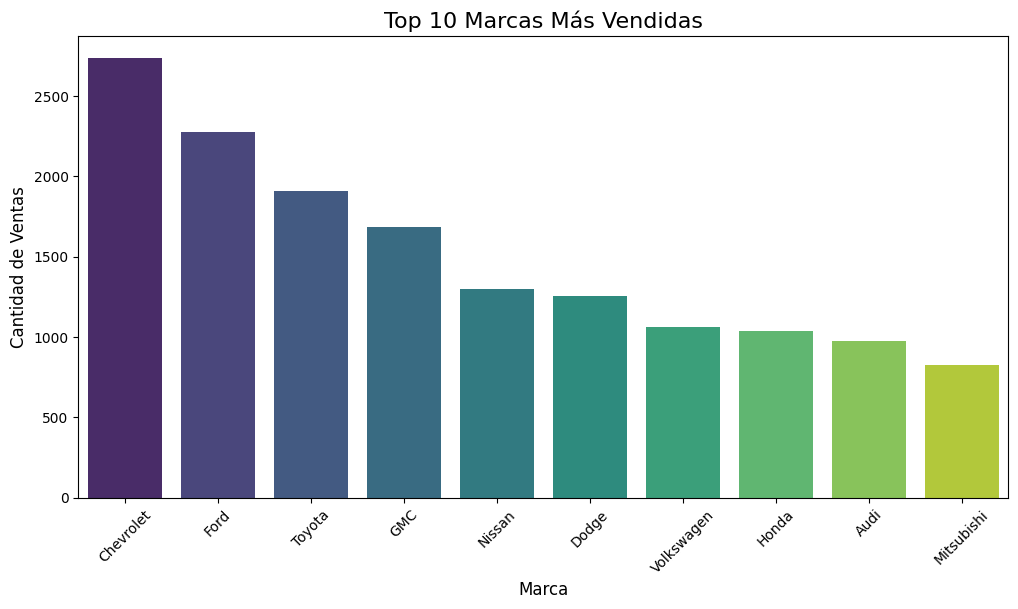

C:\Users\iabd\AppData\Local\Temp\ipykernel_17992\1502984996.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_marcas.index, y=top_marcas.values, palette='viridis')


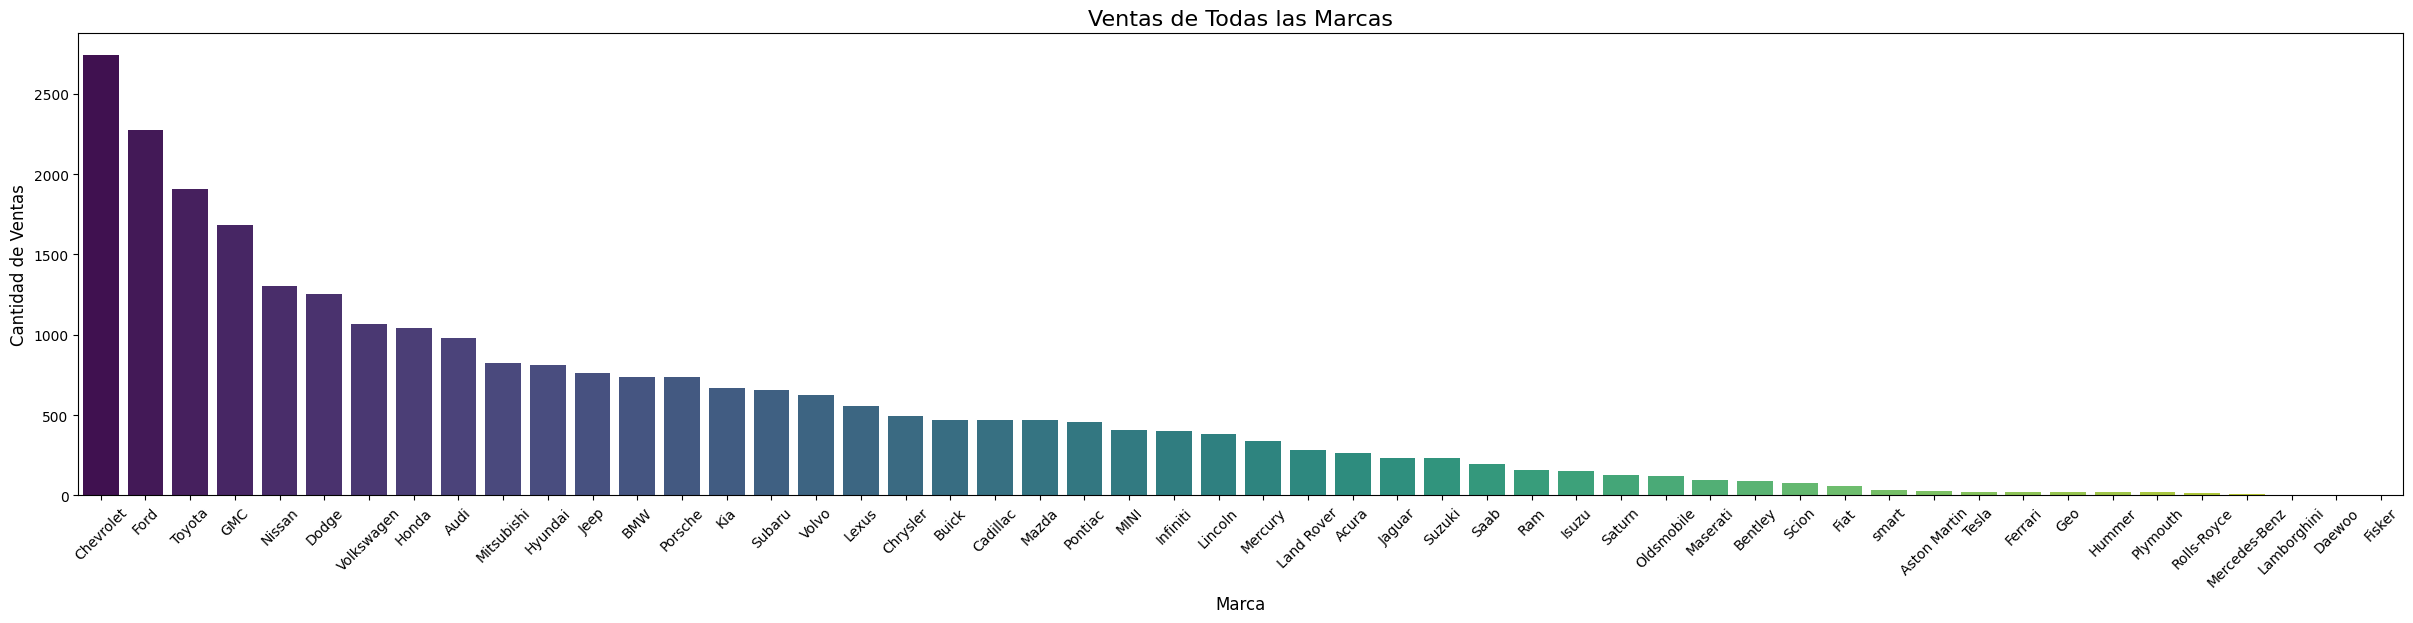

In [32]:
# Marcas más vendidas
plt.figure(figsize=(12, 6))
top_marcas = df['Marca'].value_counts().nlargest(10)
sns.barplot(x=top_marcas.index, y=top_marcas.values, palette='viridis')
plt.title('Top 10 Marcas Más Vendidas', fontsize=16)
plt.xlabel('Marca', fontsize=12)
plt.ylabel('Cantidad de Ventas', fontsize=12)
plt.xticks(rotation=45)
plt.show()

# Todas las marcas
plt.figure(figsize=(30, 6))
top_marcas = df['Marca'].value_counts()
sns.barplot(x=top_marcas.index, y=top_marcas.values, palette='viridis')
plt.title('Ventas de Todas las Marcas', fontsize=16)
plt.xlabel('Marca', fontsize=12)
plt.ylabel('Cantidad de Ventas', fontsize=12)
plt.xticks(rotation=45)
plt.show()

### **Observaciones:**
- La marca estadounidense Chevrolet es la marca que más ventas ha realizado junto a la también americana Ford y la japonesa Toyota, mientras que la estadounidense Fisker, la coreana Daewoo y la italiana Lamborghini, las que menos

## **2.- Barplot — Precio promedio de venta por marca (Top 10)**

- Qué muestra: media de PrecioVenta por Marca.
- Qué buscar: marcas premium vs masivas; dispersiones extrañas.
- Interpretación: marcas con precio promedio alto suelen ser premium, pero verificar número de observaciones por marca (una media con 3 registros es poco fiable).
- Cuidado: la media es sensible a outliers; revisar mediana y IQR.
- Incluye: Una gráfica mostrando todas las marcas

C:\Users\iabd\AppData\Local\Temp\ipykernel_17992\3116899250.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=promedio_precios.index, y=promedio_precios.values, palette='magma')


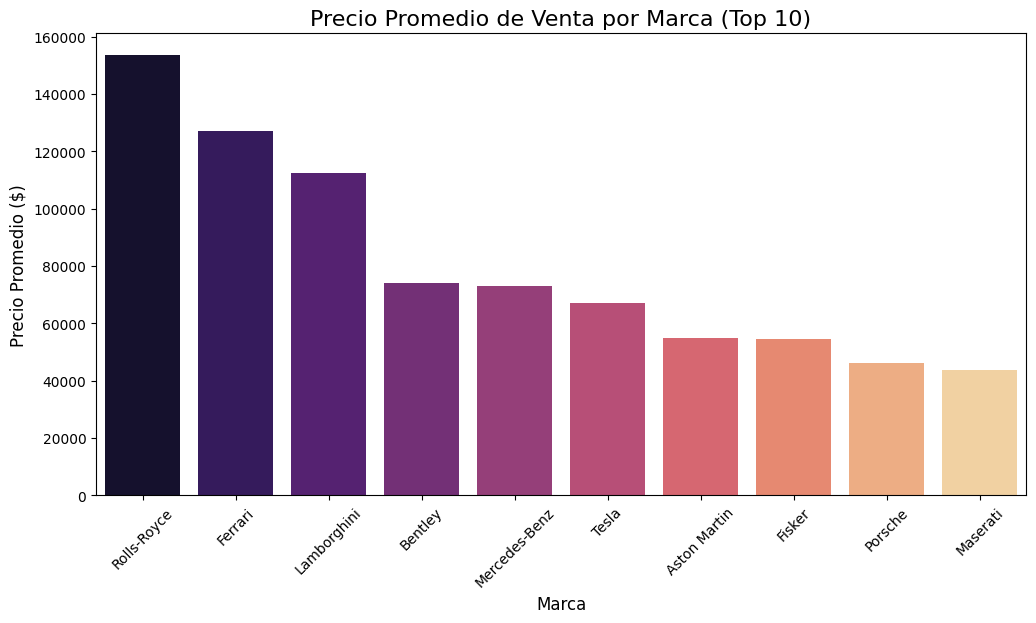

C:\Users\iabd\AppData\Local\Temp\ipykernel_17992\3116899250.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=promedio_precios.index, y=promedio_precios.values, palette='magma')


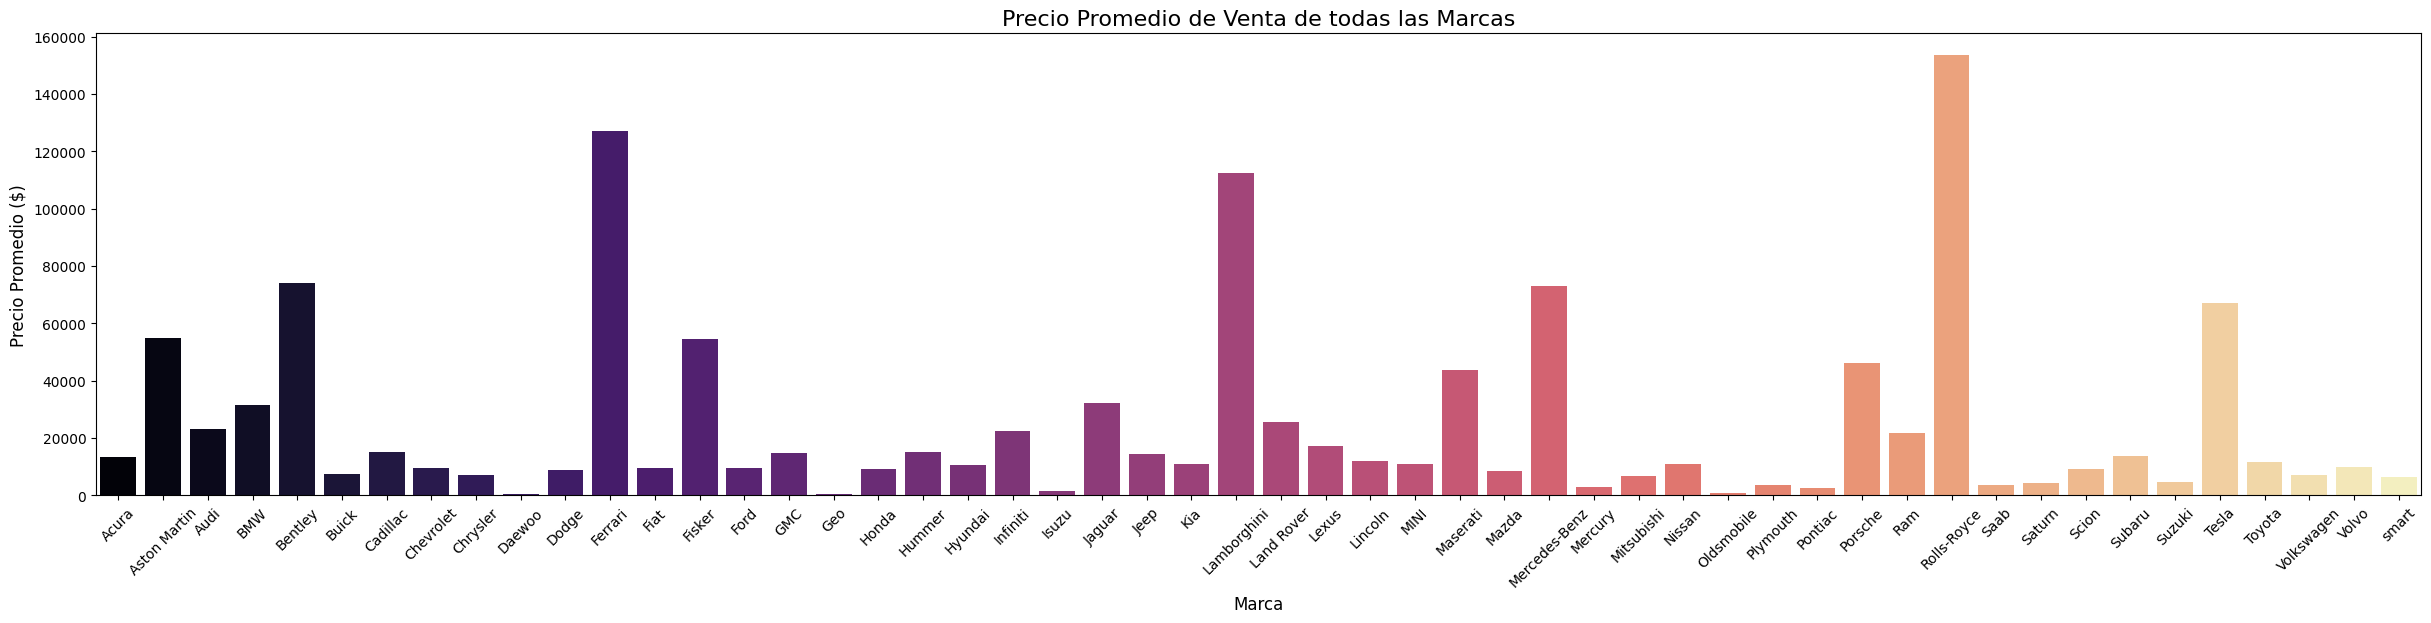

In [33]:
# Precio promedio de venta por marca

plt.figure(figsize=(12, 6))
promedio_precios = df.groupby('Marca')['Precio'].mean().nlargest(10)
sns.barplot(x=promedio_precios.index, y=promedio_precios.values, palette='magma')
plt.title('Precio Promedio de Venta por Marca (Top 10)', fontsize=16)
plt.xlabel('Marca', fontsize=12)
plt.ylabel('Precio Promedio ($)', fontsize=12)
plt.xticks(rotation=45)
plt.show()


plt.figure(figsize=(30, 6))
promedio_precios = df.groupby('Marca')['Precio'].mean()
sns.barplot(x=promedio_precios.index, y=promedio_precios.values, palette='magma')
plt.title('Precio Promedio de Venta de todas las Marcas', fontsize=16)
plt.xlabel('Marca', fontsize=12)
plt.ylabel('Precio Promedio ($)', fontsize=12)
plt.xticks(rotation=45)
plt.show()

### **Observaciones:**
- Rolls Royce tiene el promedio más caro junto con Ferrari y Lamborghini (Esta última a pesar de ser la tercera que menos vende, se deduce entonces que es una marca de autos de lujo)
- Oldsmobile, Geo, Isuzu y Daewoo tienen un promedio muy bajo, posiblemente debido a la escasez de datos de coches de esta marca en el dataframe


## **3.- Scatter — Cilindros vs Precio**

- Qué muestra: relación entre Cilindros y PrecioVenta.
- Qué buscar: tendencia positiva (más cilindros → mayor precio) o no. Outliers (vehículos con muchos cilindros pero bajo precio).
- Interpretación: correlación sugerente de que motores más grandes implican coches más caros.
- Cuidado: correlación no implica causalidad; posibles confounders (marca, año).

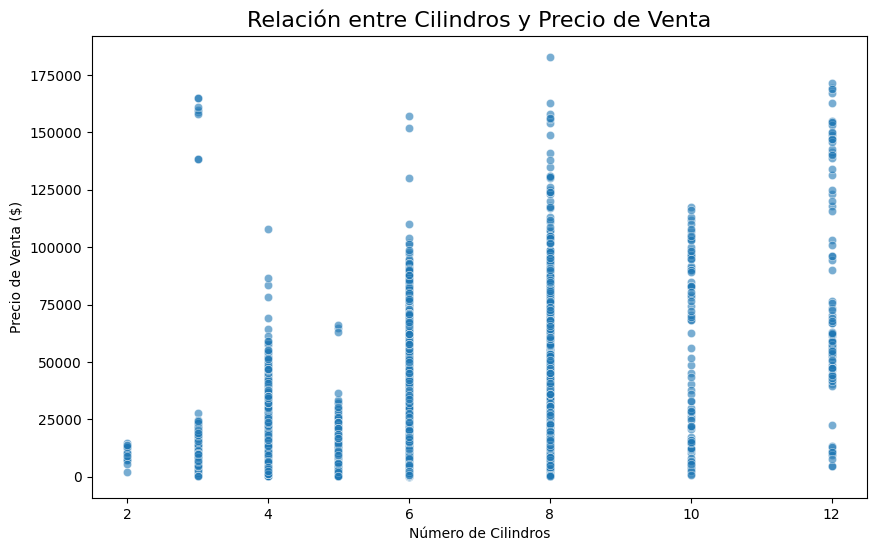

In [34]:
# Relación cilindrada - precio
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Cilindros', y='Precio', data=df, alpha=0.6)
plt.title('Relación entre Cilindros y Precio de Venta', fontsize=16)
plt.xlabel('Número de Cilindros')
plt.ylabel('Precio de Venta ($)')
plt.show()

### **Observaciones:**
- Gran cantidad de vehículos en 6, 10 y sobretodo 8 cilindros, con cantidad significativa también de 12 cilindros
- En promedio, los coches más caros están en los de 8 y 12 cilindros, con especial mención a una pequeña cantidad de vehículos de 3 cilindros de alto precio y un par de vehículos de 6


## **4.- Barplot — Cilindrada media por tipo de combustible**

- Qué muestra: promedio de Cilindros por Combustible.
- Qué buscar: si híbridos/eléctricos tienen menos cilindros (o NaN).
- Interpretación: posible confirmación de que ciertos combustibles usan motores más pequeños (por diseño).
- Cuidado: mezcla de unidades o datos nulos.

C:\Users\iabd\AppData\Local\Temp\ipykernel_17992\1920634000.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='Combustible', y='Cilindros', data=df, estimator='mean', ci=None, palette='cubehelix')
C:\Users\iabd\AppData\Local\Temp\ipykernel_17992\1920634000.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Combustible', y='Cilindros', data=df, estimator='mean', ci=None, palette='cubehelix')


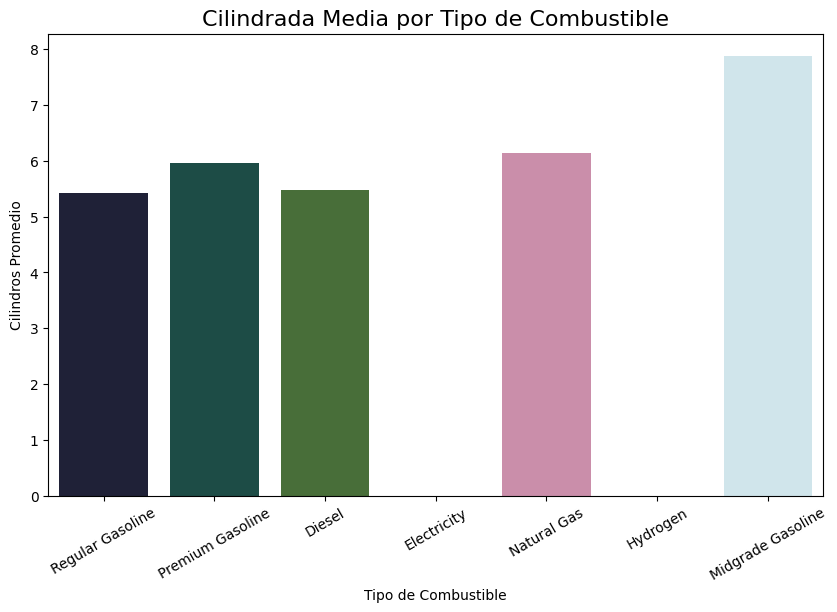

In [35]:
# Cilindrada media por tipo de combustible
plt.figure(figsize=(10, 6))
sns.barplot(x='Combustible', y='Cilindros', data=df, estimator='mean', ci=None, palette='cubehelix')
plt.title('Cilindrada Media por Tipo de Combustible', fontsize=16)
plt.xlabel('Tipo de Combustible')
plt.ylabel('Cilindros Promedio')
plt.xticks(rotation=30)
plt.show()

### **Observaciones:**
- Los coches de tipo Midgrade Gasoline son los que tienen mayor cilindrada promedio
- Los de tipo Gasolina Regular y Premium, al tener mayor variedad y gran cantidad de registros, tienen un promedio de 5,5 y 6 habiendo cilindradas de entre 6 y 12 en ambos casos


## **5.- Boxplot — Distribución del precio por tipo de combustible**

- Qué muestra: mediana, IQR y outliers de PrecioVenta por Combustible.
- Qué buscar: diferencias de mediana entre combustibles, presencia de outliers (coches de lujo).
- Interpretación: diésel/gasolina/híbrido/eléctrico pueden mostrar claras diferencias de precio.
- Cuidado: escalas y outliers extremos pueden ocultar la variación central.

C:\Users\iabd\AppData\Local\Temp\ipykernel_17992\3235991817.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Combustible', y='Precio', data=df, palette='Set2')


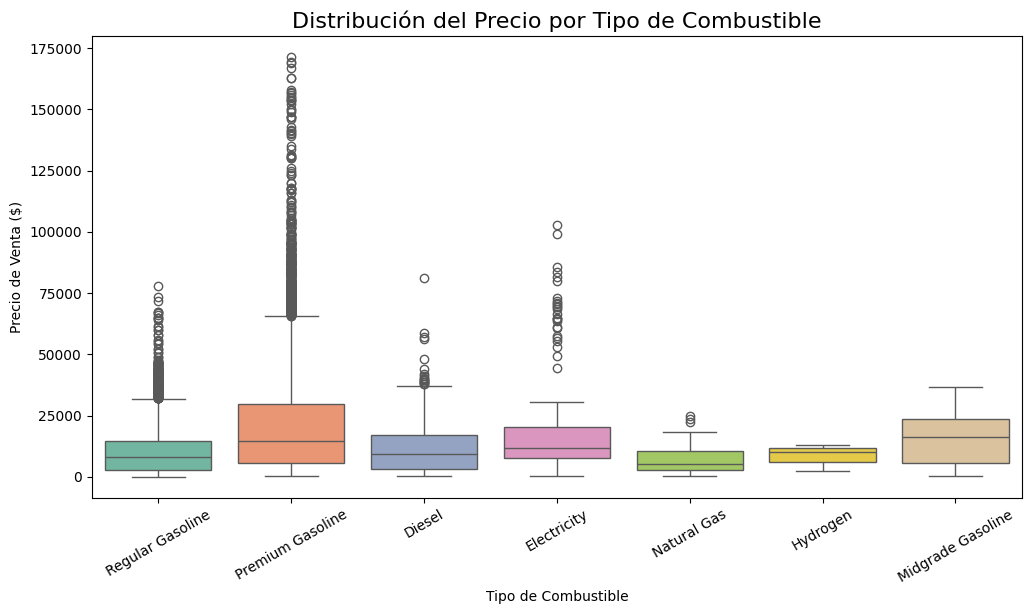

In [36]:
# Distribución precio por tipo de combustible
plt.figure(figsize=(12, 6))
sns.boxplot(x='Combustible', y='Precio', data=df, palette='Set2')
plt.title('Distribución del Precio por Tipo de Combustible', fontsize=16)
plt.xlabel('Tipo de Combustible')
plt.ylabel('Precio de Venta ($)')
plt.xticks(rotation=30)
plt.show()

### **Observaciones:**
- Los coches más caros están en los de tipo Gasolina Premium
- Los más baratos, en los de tipo Hidrógeno
- Aunque la mayoría de los de Gasolina Regular son muy baratos, al igual que los eléctricos, existe una notable cantidad de outliers tirando a un precio más caro
- Mucha variedad de precio en la mayoría de los de Midgrade Gasoline y Gasolina Premium

## **6.- Boxplot — Distribución de precios por tipo de transmisión**

* **Qué muestra:** cómo varía el precio de los vehículos según el tipo de transmisión (manual, automática, CVT...).
* **Qué buscar:** si las transmisiones automáticas tienden a tener precios más altos.
* **Interpretación:** una diferencia significativa podría reflejar mayor adopción de transmisiones automáticas en gamas altas o modelos modernos.
* **Cuidado:** revisar valores atípicos o transmisiones poco frecuentes que distorsionen el gráfico.


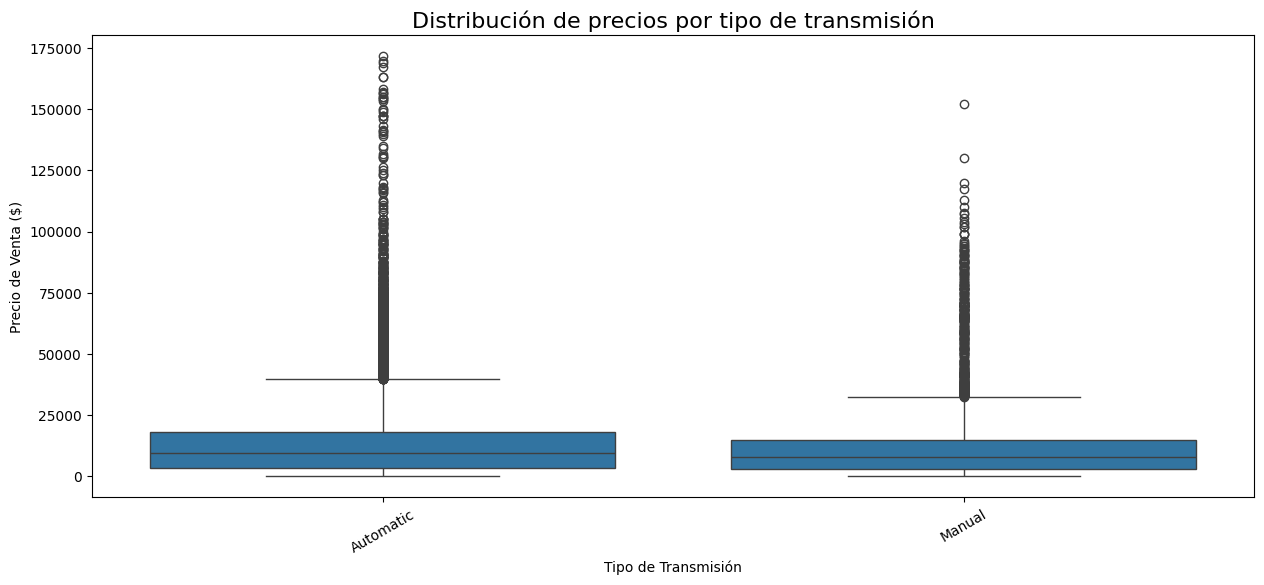

In [37]:
plt.figure(figsize=(15,6))
sns.boxplot(x='Transmision', y='Precio', data=df)
plt.title('Distribución de precios por tipo de transmisión', fontsize=16)
plt.xlabel('Tipo de Transmisión')
plt.ylabel('Precio de Venta ($)')
plt.xticks(rotation=30)
plt.show()

### **Observaciones:**
- Distribución de precios muy similar entre vehículos con una leve ventaja de precio en los outliers para los de tipo Automático

## **7.- Countplot — Frecuencia de vehículos por tipo de combustible**

* Qué muestra: cuántos vehículos hay de cada tipo de combustible.
* Qué buscar: predominancia de gasolina, baja representación de eléctricos, etc.
* Interpretación: muestra la composición del parque automotor del dataset.
* Cuidado: combinar etiquetas similares (“Gasoline” / “Gasoline Fuel”) si existen duplicados.


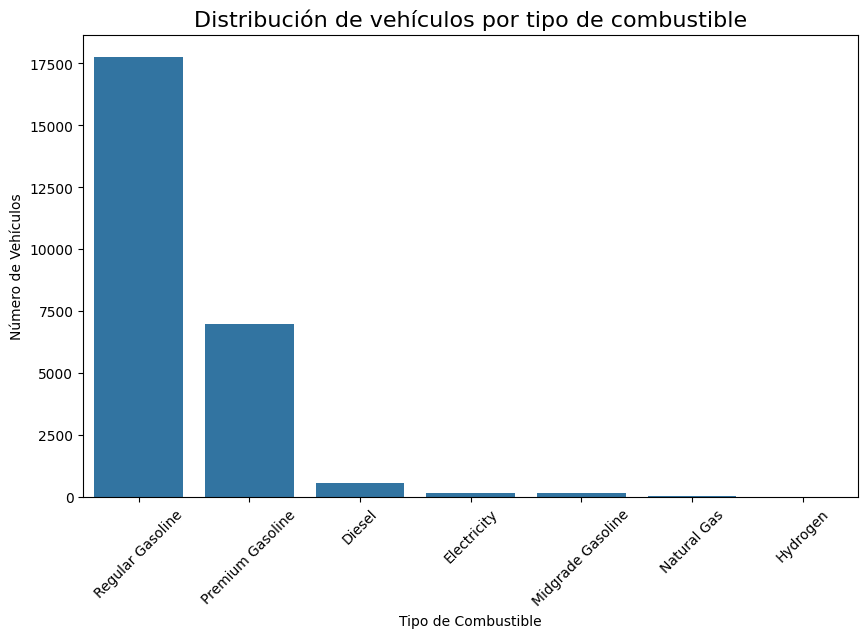

In [38]:
plt.figure(figsize=(10,6))
sns.countplot(x='Combustible', data=df, order=df['Combustible'].value_counts().index)
plt.title('Distribución de vehículos por tipo de combustible', fontsize=16)
plt.xlabel('Tipo de Combustible')
plt.ylabel('Número de Vehículos')
plt.xticks(rotation=45)
plt.show()


### **Observaciones:** 
* Gran cantidad de vehículos de Gasolina Regular y Premium, deduciendo que el combustible reinante entre los coches hoy día es la Gasolina Regular
* Escasos vehículos de Gas Natural e Hidrógeno


## **8.- Boxplot — Distribución precio por tipo de combustible**

- Qué muestra: distribuciones de precio de los vehículos en relación a su tipo de combustible.
- Qué buscar: si existe relación entre estas variables y cual es su impacto.
- Interpretación: una diferencia significativa podría reflejar dicho impacto del tipo de combustible que un vehículo consume en relación a su precio.
- Cuidado: revisar valores atípicos o transmisiones poco frecuentes que distorsionen el gráfico.

C:\Users\iabd\AppData\Local\Temp\ipykernel_17992\1956597309.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Combustible', y='Millas', palette='Set2')


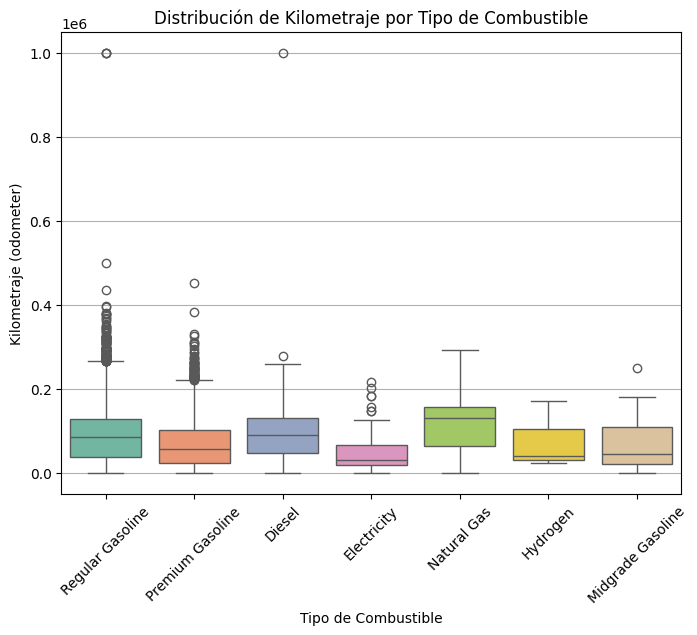

In [39]:
# Distribución precio por tipo de combustible
plt.figure(figsize=(8,6))
sns.boxplot(data=df, x='Combustible', y='Millas', palette='Set2')
plt.title("Distribución de Kilometraje por Tipo de Combustible")
plt.xlabel("Tipo de Combustible")
plt.ylabel("Kilometraje (odometer)")
plt.xticks(rotation=45)
plt.grid(True, axis='y')
plt.show()


### **Observaciones:**
* Los coches de Gasolina regular y Premium tienen generalmente más kilometraje si tomamos valores outliers
* Sin embargo, en promedio, los de Gas Natural son quienes más kilometraje tienen
* Los eléctricos son los que en promedio, menos rodaje tienen

## **9.- Heatmap — Matriz de correlación entre variables Kilometraje, Año y Precio**

- Qué muestra: correlaciones entre columnas numéricas (Año, Kilometraje y Precio).
- Qué buscar: variables con alta correlación con Precio.
- Interpretación: correlación alta tanto positiva como negativa, entre todas las variables.
- Cuidado: correlación lineal sólo; outliers pueden inflar o reducir r.

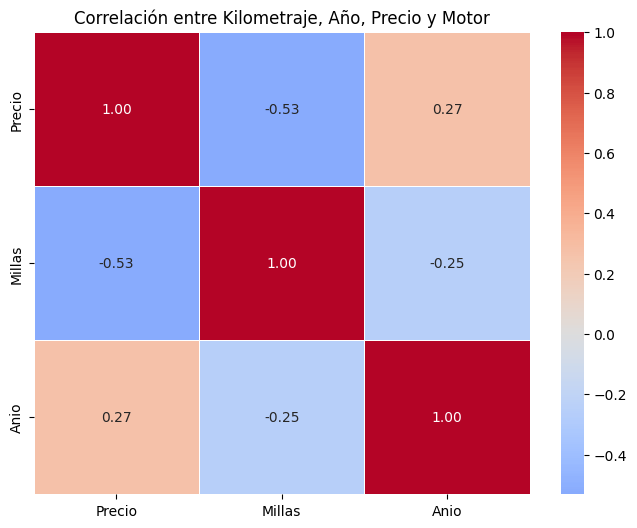

In [40]:
plt.figure(figsize=(8,6))
corr = df[['Precio', 'Millas', 'Anio']].corr()

sns.heatmap(
    corr, annot=True, cmap='coolwarm', center=0,
    fmt=".2f", linewidths=0.5
)
plt.title("Correlación entre Kilometraje, Año, Precio y Motor")
plt.show()


### **Observaciones:** 
* Relación Odometer vs Precio: Es una relación inversa significativa. A mayor kilometraje, menor precio de venta.
* Relación Año vs Precio: Es una relación también inversa pero de menor impacto en el precio. A mayor antigüedad de matriculación, menor precio de venta.
* Relación Odometer vs Año: Es una relación positiva, quiere decir que a mayor año de matriculación, mayor kilometraje tiene el vehículo.


# Ahora arreglaremos el dataframe para poder empezar con la división
- Quitamos valores nulos y reducimos un poco el dataframe para tener todos los datos en orden

In [41]:
df = df[df["Anio"].notnull()]
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 25656 entries, 0 to 26807
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Anio                  25656 non-null  object 
 1   Marca                 25656 non-null  object 
 2   Modelo                25656 non-null  object 
 3   SubModelo             25564 non-null  object 
 4   Condicion             20666 non-null  float64
 5   Millas                25630 non-null  float64
 6   Color                 25595 non-null  object 
 7   Interior              25595 non-null  object 
 8   Precio                25656 non-null  float64
 9   MPG                   25656 non-null  object 
 10  Cilindros             25492 non-null  float64
 11  Motor                 25493 non-null  float64
 12  Traccion              25311 non-null  object 
 13  Combustible           25656 non-null  object 
 14  Transmision           25650 non-null  object 
 15  Tamanio_del_vehiculo  25

In [42]:
df.head()

,Anio,Marca,Modelo,SubModelo,Condicion,Millas,Color,Interior,Precio,MPG,Cilindros,Motor,Traccion,Combustible,Transmision,Tamanio_del_vehiculo
0,2024,Kia,Sorento FWD,LX,5.0,16639.0,white,black,21500.0,23,4.0,2.5,Front-Wheel Drive,Regular Gasoline,Automatic,Small Sport Utility Vehicle 2WD
1,2018,Kia,Sorento FE AWD,LX,5.0,9393.0,white,beige,21500.0,21,6.0,3.3,All-Wheel Drive,Regular Gasoline,Automatic,Small Sport Utility Vehicle 4WD
2,1986,BMW,3 Series,328i SULEV,45.0,1331.0,gray,black,30000.0,20,6.0,2.7,Rear-Wheel Drive,Regular Gasoline,Automatic,Subcompact Cars
3,2018,Volvo,S60 AWD,T5,41.0,14282.0,white,black,27750.0,26,4.0,2.0,All-Wheel Drive,Premium Gasoline,Automatic,Compact Cars
4,1985,BMW,6 Series,650i,43.0,2641.0,gray,black,67000.0,17,6.0,3.4,Rear-Wheel Drive,Regular Gasoline,Automatic,Subcompact Cars


In [43]:
le_marca = LabelEncoder()
le_modelo = LabelEncoder()
le_submodelo = LabelEncoder()
le_color = LabelEncoder()
le_Interior = LabelEncoder()
le_Traccion = LabelEncoder()
le_Combustible = LabelEncoder()
le_Transmision = LabelEncoder()
le_Tamanio_delvehiculo = LabelEncoder()
			
df["Tamanio_del_vehiculo"] = le_Tamanio_delvehiculo.fit_transform(df["Tamanio_del_vehiculo"])
df["Transmision"] = le_Transmision.fit_transform(df["Transmision"])
df["Combustible"] = le_Combustible.fit_transform(df["Combustible"])
df["Traccion"] = le_Traccion.fit_transform(df["Traccion"])
df["Interior"] = le_Interior.fit_transform(df["Interior"])
df["Color"] = le_color.fit_transform(df["Color"])
df["Marca"] = le_marca.fit_transform(df["Marca"])
df["Modelo"] = le_modelo.fit_transform(df["Modelo"])
df["SubModelo"] = le_submodelo.fit_transform(df["SubModelo"])
df["Anio"] = pd.to_numeric(df["Anio"], errors="coerce")
df["MPG"] = pd.to_numeric(df["MPG"], errors="coerce")
df["Millas"] = pd.to_numeric(df["Millas"], errors="coerce")


C:\Users\iabd\AppData\Local\Temp\ipykernel_17992\3706754720.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Tamanio_del_vehiculo"] = le_Tamanio_delvehiculo.fit_transform(df["Tamanio_del_vehiculo"])
C:\Users\iabd\AppData\Local\Temp\ipykernel_17992\3706754720.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Transmision"] = le_Transmision.fit_transform(df["Transmision"])
C:\Users\iabd\AppData\Local\Temp\ipykernel_17992\3706754720.py:13: SettingWithCopyWarning: 
A value is trying to be set on a

In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 25656 entries, 0 to 26807
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Anio                  25656 non-null  int64  
 1   Marca                 25656 non-null  int64  
 2   Modelo                25656 non-null  int64  
 3   SubModelo             25656 non-null  int64  
 4   Condicion             20666 non-null  float64
 5   Millas                25630 non-null  float64
 6   Color                 25656 non-null  int64  
 7   Interior              25656 non-null  int64  
 8   Precio                25656 non-null  float64
 9   MPG                   25656 non-null  int64  
 10  Cilindros             25492 non-null  float64
 11  Motor                 25493 non-null  float64
 12  Traccion              25656 non-null  int64  
 13  Combustible           25656 non-null  int64  
 14  Transmision           25656 non-null  int64  
 15  Tamanio_del_vehiculo  25

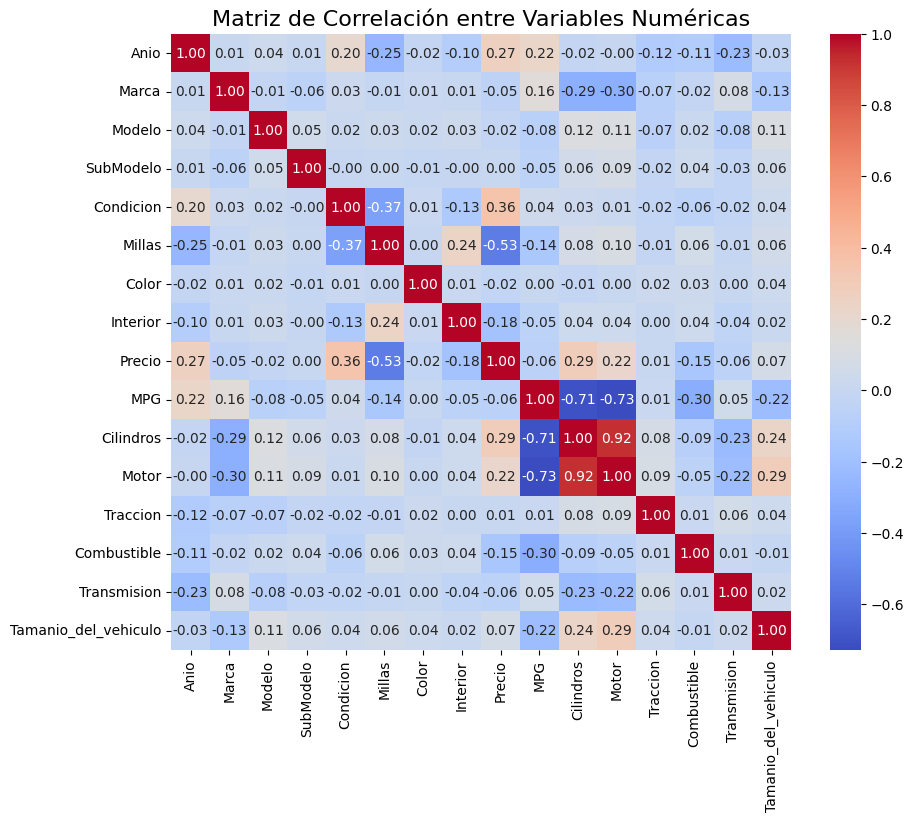

In [45]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación entre Variables Numéricas', fontsize=16)
plt.show()

### **Observaciones:**
* Mucha relación entre algunos campos
  * Tanto positiva: Motor – Cilindros / Condición – Precio / Motor – Tamaño de Vehículo / Odometer – Interior
  * Como negativa: Motor – MPG / Cilindros – MPG / Combustible – MPG / Cilindros y Motor – Marca / Odometer – Precio / Odometer – Condición


In [46]:
print(df["Precio"].mean())
df = df[df["Precio"]>1000]
len(df)

13177.592804801996


23285

In [47]:
X = df.drop(columns=['Precio'])
y = df['Precio']

In [48]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42)

In [49]:
X_train["SubModelo"] = X_train["SubModelo"].fillna(X_train["Modelo"])
X_train["Color"] = X_train["Color"].fillna("black")
X_train["Interior"] = X_train["Interior"].fillna("black")
X_train["Condicion"] = X_train["Condicion"].fillna(X_train["Condicion"].median())
X_train["Cilindros"] = X_train["Cilindros"].fillna(X_train["Cilindros"].median())
X_train["Millas"] = X_train["Millas"].fillna(X_train["Millas"].median())
X_train["Motor"] = X_train["Motor"].fillna(X_train["Motor"].median())
X_train["Transmision"] = X_train["Transmision"].fillna("Automatic 4-spd")
X_train["Traccion"] = X_train["Traccion"].fillna("No traccion")

In [50]:
le_marca = LabelEncoder()
le_modelo = LabelEncoder()
le_submodelo = LabelEncoder()
le_color = LabelEncoder()
le_Interior = LabelEncoder()
le_Traccion = LabelEncoder()
le_Combustible = LabelEncoder()
le_Transmision = LabelEncoder()
le_Tamanio_delvehiculo = LabelEncoder()
			

X_train["Tamanio_del_vehiculo"] = le_Tamanio_delvehiculo.fit_transform(X_train["Tamanio_del_vehiculo"])
X_train["Transmision"] = le_Transmision.fit_transform(X_train["Transmision"])
X_train["Combustible"] = le_Combustible.fit_transform(X_train["Combustible"])
X_train["Traccion"] = le_Traccion.fit_transform(X_train["Traccion"])
X_train["Interior"] = le_Interior.fit_transform(X_train["Interior"])
X_train["Color"] = le_color.fit_transform(X_train["Color"])
X_train["Marca"] = le_marca.fit_transform(X_train["Marca"])
X_train["Modelo"] = le_modelo.fit_transform(X_train["Modelo"])
X_train["SubModelo"] = le_submodelo.fit_transform(X_train["SubModelo"])
X_train["Anio"] = pd.to_numeric(X_train["Anio"], errors="coerce")
X_train["MPG"] = pd.to_numeric(X_train["MPG"], errors="coerce")
X_train["Millas"] = pd.to_numeric(X_train["Millas"], errors="coerce")

In [51]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16299 entries, 14807 to 17742
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Anio                  16299 non-null  int64  
 1   Marca                 16299 non-null  int64  
 2   Modelo                16299 non-null  int64  
 3   SubModelo             16299 non-null  int64  
 4   Condicion             16299 non-null  float64
 5   Millas                16299 non-null  float64
 6   Color                 16299 non-null  int64  
 7   Interior              16299 non-null  int64  
 8   MPG                   16299 non-null  int64  
 9   Cilindros             16299 non-null  float64
 10  Motor                 16299 non-null  float64
 11  Traccion              16299 non-null  int64  
 12  Combustible           16299 non-null  int64  
 13  Transmision           16299 non-null  int64  
 14  Tamanio_del_vehiculo  16299 non-null  int64  
dtypes: float64(4), int64

In [52]:
X_test["SubModelo"] = X_test["SubModelo"].fillna(X_test["Modelo"])
X_test["Color"] = X_test["Color"].fillna("black")
X_test["Interior"] = X_test["Interior"].fillna("black")
X_test["Condicion"] = X_test["Condicion"].fillna(X_train["Condicion"].median())
X_test["Cilindros"] = X_test["Cilindros"].fillna(X_train["Cilindros"].median())
X_test["Millas"] = X_test["Millas"].fillna(X_train["Millas"].median())
X_test["Motor"] = X_test["Motor"].fillna(X_train["Motor"].median())
X_test["Transmision"] = X_test["Transmision"].fillna("Automatic 4-spd")
X_test["Traccion"] = X_test["Traccion"].fillna("No traccion")

In [53]:
X_train.to_csv('X_train.csv', index=False, encoding='utf-8')
X_test.to_csv('X_test.csv', index=False, encoding='utf-8')
y_train.to_csv('y_train.csv', index=False, encoding='utf-8')
y_test.to_csv('y_test.csv', index=False, encoding='utf-8')

In [54]:
print(f"\n Datos de entrenamiento: {len(X_train)} coches ({len(X_train)/len(df)*100:.1f}%)")
print(f" Datos de prueba: {len(X_test)} coches ({len(X_test)/len(df)*100:.1f}%)")


 Datos de entrenamiento: 16299 coches (70.0%)
 Datos de prueba: 6986 coches (30.0%)


In [55]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [56]:
X_train_scaled_df = pd.DataFrame(X_train_scaled)
X_test_scaled_df = pd.DataFrame(X_test_scaled)

In [57]:
X_train_scaled_df.to_csv('X_train_Escalado.csv', index=False, encoding='utf-8')
X_test_scaled_df.to_csv('X_test_Escalado.csv', index=False, encoding='utf-8')

## **10.- Lineplot — Evolución del precio promedio por año**

- Qué muestra: PrecioVenta promedio por Anio.
- Qué buscar: tendencia temporal: depreciación natural, renovación de modelos, picos inusuales.
- Interpretación: precios medios decrecientes con año de fabricación (coches más antiguos más baratos).
- Cuidado: si Anio representa año de fabricación, conviene agrupar por rangos (decenas) si hay pocos valores. Asegurate de usar groupby('Anio').mean().

C:\Users\iabd\AppData\Local\Temp\ipykernel_17992\2555758961.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(x='Anio', y='Precio', data=df, ci=None, marker='o')


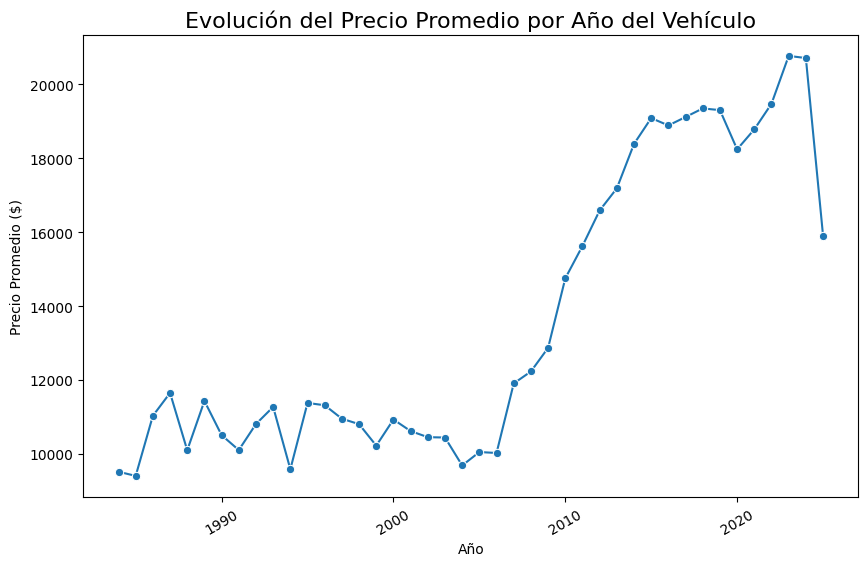

In [58]:
# Evolución precio promedio por año
plt.figure(figsize=(10, 6))
sns.lineplot(x='Anio', y='Precio', data=df, ci=None, marker='o')
plt.title('Evolución del Precio Promedio por Año del Vehículo', fontsize=16)
plt.xlabel('Año')
plt.ylabel('Precio Promedio ($)')
plt.xticks(rotation=30)
plt.show()


### **Observaciones:**
- Evolución constante del precio promedio de los vehículos cuanto más moderno es su año, con un ascenso importante entre los años 2005 hasta 2015
- Leves ‘cliffs’ o descensos en los años 1994 y 2019 seguramente debido a falta de información de coches de estos años
- Descenso muy grande, o Cliff en el año 2025 seguramente debido también a la falta de registros de vehículos de este año
